In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [53]:
import os
import glob
import pandas as pd

# Define the path to your labels directory
# (Keeping the 'lables' spelling from your directory structure)
label_dir = '/home/arch/LCPB/runs/detect/predict-f1.1/labels'

# List to accumulate rows for the DataFrame
data_list = []

# Find all .txt files in the specified directory
txt_files = glob.glob(os.path.join(label_dir, '*.txt'))

for file_path in txt_files:
    # Read the file line by line
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    for line in lines:
        parts = line.strip().split()
        
        # YOLO format standard has 5 primary columns: class, x, y, w, h
        # (It might have a 6th confidence column if exported from predictions)
        if len(parts) >= 5:
            class_id = parts[0]
            x = float(parts[1])
            y = float(parts[2])
            w = float(parts[3])
            h = float(parts[4])
            
            # Optional: extract confidence if it exists in the prediction output
            conf = float(parts[5]) if len(parts) == 6 else None
            
            # Append data row
            row = {
                'filename': os.path.basename(file_path),
                'class_id': int(class_id),
                'x': x,
                'y': y,
                'w': w,
                'h': h
            }
            
            if conf is not None:
                row['confidence'] = conf
                
            data_list.append(row)

# Create the pandas DataFrame
df = pd.DataFrame(data_list)

# Quick look at the resulting DataFrame
print(f"Loaded {len(df)} bounding boxes.")
print(df.head())

df['class_id'] = 'Impact Crater'
df['type']= 'f1'
df['conf'] = 0.5

Loaded 1345 bounding boxes.
          filename  class_id        x        y    w    h
0  tile_000075.txt         0  0.78125  0.40625  0.0  0.0
1  tile_000075.txt         0  0.78125  0.34375  0.0  0.0
2  tile_000075.txt         0  0.71875  0.71875  0.0  0.0
3  tile_000075.txt         0  0.71875  0.40625  0.0  0.0
4  tile_000075.txt         0  0.71875  0.78125  0.0  0.0


In [54]:
df

,filename,class_id,x,y,w,h,type,conf
0,tile_000075.txt,Impact Crater,0.78125,0.40625,0.0,0.0,f1,0.5
1,tile_000075.txt,Impact Crater,0.78125,0.34375,0.0,0.0,f1,0.5
2,tile_000075.txt,Impact Crater,0.71875,0.71875,0.0,0.0,f1,0.5
3,tile_000075.txt,Impact Crater,0.71875,0.40625,0.0,0.0,f1,0.5
4,tile_000075.txt,Impact Crater,0.71875,0.78125,0.0,0.0,f1,0.5
...,...,...,...,...,...,...,...,...
1340,tile_009005.txt,Impact Crater,0.65625,0.53125,0.0,0.0,f1,0.5
1341,tile_009006.txt,Impact Crater,0.53125,0.21875,0.0,0.0,f1,0.5
1342,tile_009006.txt,Impact Crater,0.46875,0.28125,0.0,0.0,f1,0.5
1343,tile_009008.txt,Impact Crater,0.59375,0.78125,0.0,0.0,f1,0.5


In [55]:
import os
import glob
import pandas as pd

# Define the path to your labels directory
# (Keeping the 'lables' spelling from your directory structure)
label_dir = '/home/arch/LCPB/runs/detect/predict-f1.2/labels'

# List to accumulate rows for the DataFrame
data_list = []

# Find all .txt files in the specified directory
txt_files = glob.glob(os.path.join(label_dir, '*.txt'))

for file_path in txt_files:
    # Read the file line by line
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    for line in lines:
        parts = line.strip().split()
        
        # YOLO format standard has 5 primary columns: class, x, y, w, h
        # (It might have a 6th confidence column if exported from predictions)
        if len(parts) >= 5:
            class_id = parts[0]
            x = float(parts[1])
            y = float(parts[2])
            w = float(parts[3])
            h = float(parts[4])
            
            # Optional: extract confidence if it exists in the prediction output
            conf = float(parts[5]) if len(parts) == 6 else None
            
            # Append data row
            row = {
                'filename': os.path.basename(file_path),
                'class_id': int(class_id),
                'x': x,
                'y': y,
                'w': w,
                'h': h
            }
            
            if conf is not None:
                row['confidence'] = conf
                
            data_list.append(row)

# Create the pandas DataFrame
df1_1 = pd.DataFrame(data_list)

# Quick look at the resulting DataFrame
print(f"Loaded {len(df1_1)} bounding boxes.")
print(df1_1.head())

# df['class_id'] = 'Impact Crater'
df1_1['type']= 'f1'
df1_1['conf']= 0.05

mapping = {
    0:'pit_skylight',
    1:'irregular_mare_patch',
    2:'apollo_site',
}
df1_1['class_id'] = df1_1['class_id'].replace(mapping)

Loaded 344 bounding boxes.
          filename  class_id         x         y         w         h
0  tile_000507.txt         2  0.956210  0.007556  0.077626  0.014579
1  tile_000509.txt         2  0.956382  0.007522  0.076875  0.014502
2  tile_000597.txt         0  0.003923  0.678537  0.007845  0.035280
3  tile_000607.txt         2  0.955208  0.957822  0.063014  0.060234
4  tile_000607.txt         2  0.955655  0.964933  0.083756  0.062596


In [56]:
DATA = pd.concat([df,df1_1],ignore_index=True)

In [57]:
DATA

,filename,class_id,x,y,w,h,type,conf
0,tile_000075.txt,Impact Crater,0.781250,0.406250,0.000000,0.000000,f1,0.50
1,tile_000075.txt,Impact Crater,0.781250,0.343750,0.000000,0.000000,f1,0.50
2,tile_000075.txt,Impact Crater,0.718750,0.718750,0.000000,0.000000,f1,0.50
3,tile_000075.txt,Impact Crater,0.718750,0.406250,0.000000,0.000000,f1,0.50
4,tile_000075.txt,Impact Crater,0.718750,0.781250,0.000000,0.000000,f1,0.50
...,...,...,...,...,...,...,...,...
1684,tile_008830.txt,apollo_site,0.805865,0.949987,0.098980,0.068200,f1,0.05
1685,tile_008830.txt,apollo_site,0.796243,0.956425,0.064919,0.063040,f1,0.05
1686,tile_008830.txt,apollo_site,0.837312,0.977149,0.088414,0.045701,f1,0.05
1687,tile_008830.txt,irregular_mare_patch,0.590066,0.712521,0.101447,0.057589,f1,0.05


Task was destroyed but it is pending!
task: <Task pending name='Task-1596' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/arch/LCPB/.venv/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-1597' coro=<Kernel.shell_main() running at /home/arch/LCPB/.venv/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/arch/LCPB/.venv/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
/home/arch/LCPB/.venv/lib/python3.14/site-packages/matplotlib/_api/__init__.py:188: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def check_in_list(values, /, **kwargs):
Task was destroyed but it is pending!
task: <Task pending name='Task-1597' coro=<Kernel.shell_main() running at /home/arch/LCPB/.venv/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


<Axes: xlabel='class_id'>

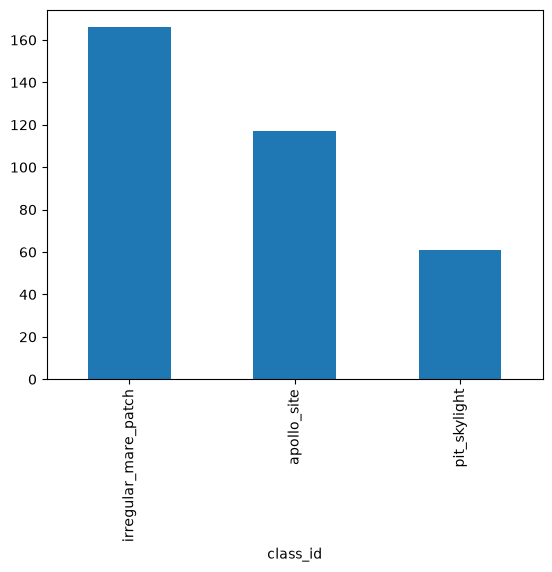

In [226]:
DATA['class_id'][DATA['conf']<.4].value_counts().sort_values(ascending=False).plot(kind = 'bar')

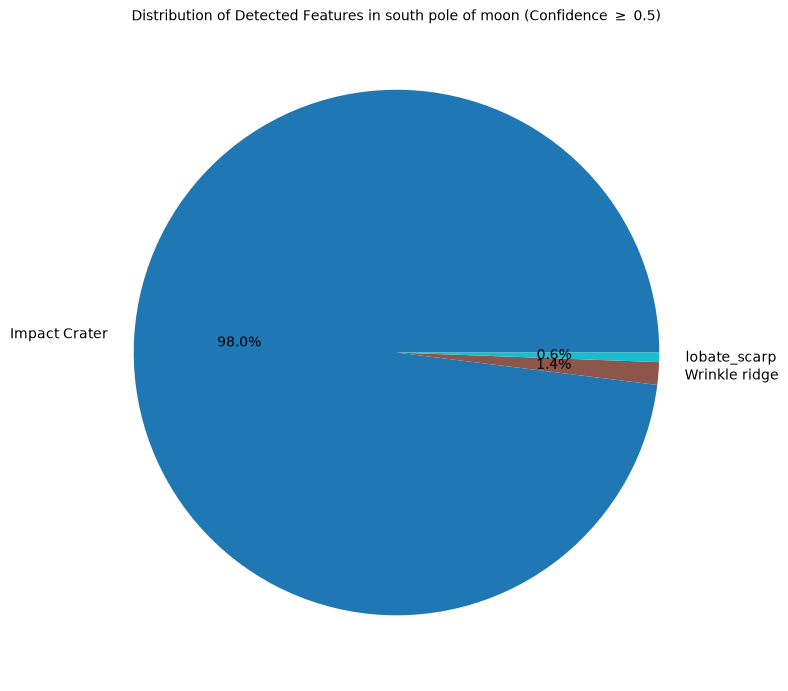

In [194]:
import matplotlib.pyplot as plt

# 1. Get the filtered counts
class_counts = DATA[DATA['conf'] > 0.4]['class_id'].value_counts().sort_values(ascending=False)

# 2. Plot as a pie chart (circle plot)
plt.figure(figsize=(8, 8))
class_counts.plot(
    kind='pie', 
    autopct='%1.1f%%',       # Displays percentages with 1 decimal place (e.g., 45.2%)
    startangle=0,          # Starts the first slice at the top vertical axis
    cmap='tab10',           # Uses a clean, distinct color palette
    ylabel=''               # Removes the default vertical 'class_id' text label on the side
)

# 3. Add a clean title
plt.title(r'Distribution of Detected Features in south pole of moon (Confidence $\geq$ 0.5)', fontsize=10, pad=.0001)
plt.tight_layout()

plt.savefig("./IMG/Distribution-SPM.png")

In [59]:
import os
import glob
import pandas as pd

# Define the path to your labels directory
# (Keeping the 'lables' spelling from your directory structure)
label_dir = '/home/arch/LCPB/runs/detect/predict-f2.1/labels'

# List to accumulate rows for the DataFrame
data_list = []

# Find all .txt files in the specified directory
txt_files = glob.glob(os.path.join(label_dir, '*.txt'))

for file_path in txt_files:
    # Read the file line by line
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    for line in lines:
        parts = line.strip().split()
        
        # YOLO format standard has 5 primary columns: class, x, y, w, h
        # (It might have a 6th confidence column if exported from predictions)
        if len(parts) >= 5:
            class_id = parts[0]
            x = float(parts[1])
            y = float(parts[2])
            w = float(parts[3])
            h = float(parts[4])
            
            # Optional: extract confidence if it exists in the prediction output
            conf = float(parts[5]) if len(parts) == 6 else None
            
            # Append data row
            row = {
                'filename': os.path.basename(file_path),
                'class_id': int(class_id),
                'x': x,
                'y': y,
                'w': w,
                'h': h
            }
            
            if conf is not None:
                row['confidence'] = conf
                
            data_list.append(row)

# Create the pandas DataFrame
df2 = pd.DataFrame(data_list)

# Quick look at the resulting DataFrame
# print(f"Loaded {len(df1_1)} bounding boxes.")
# print(df1_1.head())

df2['class_id'] = 'Wrinkle ridge'
df2['type']= 'f2'
df2['conf']= 0.5

DATA = pd.concat([DATA,df2],ignore_index=True)
# mapping = {
#     0:'pit_skylight',
#     1:'irregular_mare_patch',
#     2:'apollo_site',
# }
# df1_1['class_id'] = df1_1['class_id'].replace(mapping)

In [60]:
DATA

,filename,class_id,x,y,w,h,type,conf
0,tile_000075.txt,Impact Crater,0.781250,0.406250,0.000000,0.000000,f1,0.5
1,tile_000075.txt,Impact Crater,0.781250,0.343750,0.000000,0.000000,f1,0.5
2,tile_000075.txt,Impact Crater,0.718750,0.718750,0.000000,0.000000,f1,0.5
3,tile_000075.txt,Impact Crater,0.718750,0.406250,0.000000,0.000000,f1,0.5
4,tile_000075.txt,Impact Crater,0.718750,0.781250,0.000000,0.000000,f1,0.5
...,...,...,...,...,...,...,...,...
1703,tile_003843.txt,Wrinkle ridge,0.783607,0.742060,0.432787,0.513796,f2,0.5
1704,tile_004131.txt,Wrinkle ridge,0.101083,0.633119,0.202166,0.502805,f2,0.5
1705,tile_008812.txt,Wrinkle ridge,0.486590,0.229515,0.030334,0.020577,f2,0.5
1706,tile_008830.txt,Wrinkle ridge,0.250685,0.765981,0.501371,0.468038,f2,0.5


In [61]:
import os
import glob
import pandas as pd

# Define the path to your labels directory
# (Keeping the 'lables' spelling from your directory structure)
label_dir = '/home/arch/LCPB/runs/detect/predict-f2.2/labels'

# List to accumulate rows for the DataFrame
data_list = []

# Find all .txt files in the specified directory
txt_files = glob.glob(os.path.join(label_dir, '*.txt'))

for file_path in txt_files:
    # Read the file line by line
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    for line in lines:
        parts = line.strip().split()
        
        # YOLO format standard has 5 primary columns: class, x, y, w, h
        # (It might have a 6th confidence column if exported from predictions)
        if len(parts) >= 5:
            class_id = parts[0]
            x = float(parts[1])
            y = float(parts[2])
            w = float(parts[3])
            h = float(parts[4])
            
            # Optional: extract confidence if it exists in the prediction output
            conf = float(parts[5]) if len(parts) == 6 else None
            
            # Append data row
            row = {
                'filename': os.path.basename(file_path),
                'class_id': int(class_id),
                'x': x,
                'y': y,
                'w': w,
                'h': h
            }
            
            if conf is not None:
                row['confidence'] = conf
                
            data_list.append(row)

# Create the pandas DataFrame
df2_2 = pd.DataFrame(data_list)

# Quick look at the resulting DataFrame
# print(f"Loaded {len(df1_1)} bounding boxes.")
# print(df1_1.head())

# df2_2['class_id'] = 'Wrinkle ridge'
df2_2['type']= 'f2'
df2_2['conf']= 0.5


mapping = {
    0:'lobate_scarp',
    1:'candidate_rille',
}
df2_2['class_id'] = df2_2['class_id'].replace(mapping)

DATA = pd.concat([DATA,df2_2],ignore_index=True)

<Axes: xlabel='filename'>

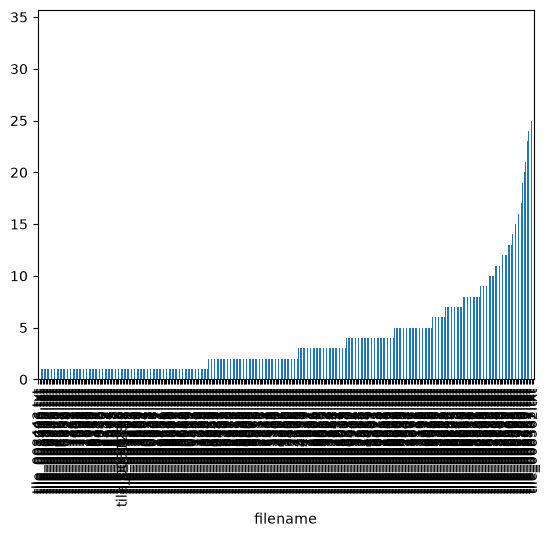

In [76]:
DATA[DATA['conf']>0.4]['filename'].value_counts().sort_values(ascending=True).plot(kind = 'bar')

In [69]:
# DATA.to_csv('DATA.csv')

Text(0.5, 0, 'All Tiles (Sorted Chronologically)')

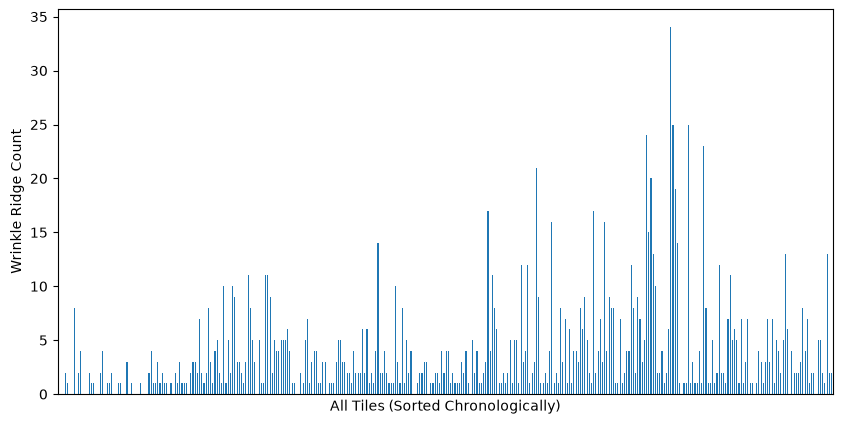

In [159]:
# 1. Get a master list of ALL unique filenames in your dataset
all_filenames = DATA['filename'].unique()

# 2. Filter for Wrinkle ridges and get their counts
wrinkle_counts = DATA[ (DATA['conf'] > 0.4) & (DATA['class_id'] == 'Impact Crater') ]['filename'].value_counts()

# 3. Reindex using ALL filenames, filling missing ones with 0, then sort chronologically
counts_chronological = wrinkle_counts.reindex(all_filenames, fill_value=0).sort_index(ascending=True)

# 4. Plot
ax = counts_chronological.plot(kind='bar', figsize=(10, 5))
ax.get_xaxis().set_ticks([]) # Hide messy labels
ax.set_ylabel('Wrinkle Ridge Count')
ax.set_xlabel('All Tiles (Sorted Chronologically)')

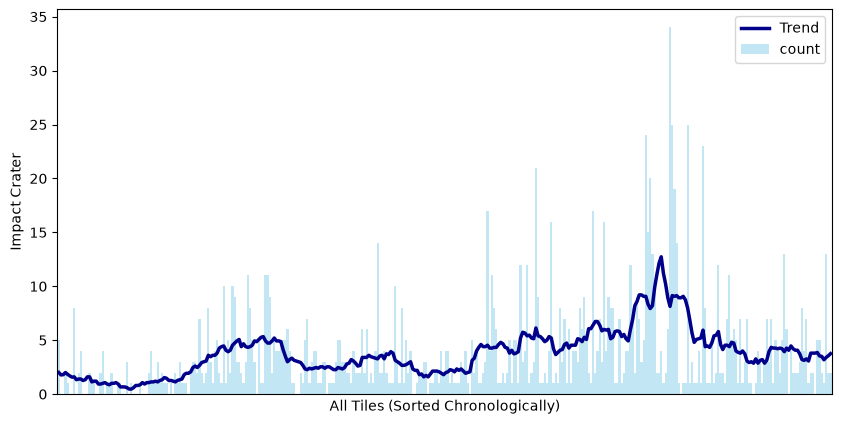

In [195]:
import matplotlib.pyplot as plt

counts_chronological = wrinkle_counts.reindex(all_filenames, fill_value=0).sort_index(ascending=True)
smoothed_counts = counts_chronological.rolling(window=15, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 5))

# Plot raw bars with some transparency (alpha) so they don't overpower the trend
counts_chronological.plot(kind='bar', ax=ax, color='skyblue', alpha=.5, width=1.0)

# Plot the smooth trend line on top
# We use a numeric range for x because bar plots use 0, 1, 2... index positions internally
ax.plot(range(len(smoothed_counts)), smoothed_counts.values, color='darkblue', linewidth=2.5, label='Trend')

ax.get_xaxis().set_ticks([])
ax.set_ylabel('Impact Crater')
ax.set_xlabel('All Tiles (Sorted Chronologically)')
plt.legend()
plt.savefig("./IMG/CratervsLocation.png")

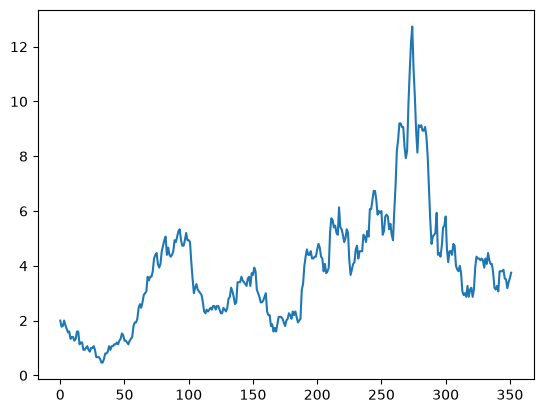

In [162]:
plt.plot(smoothed_counts.values)

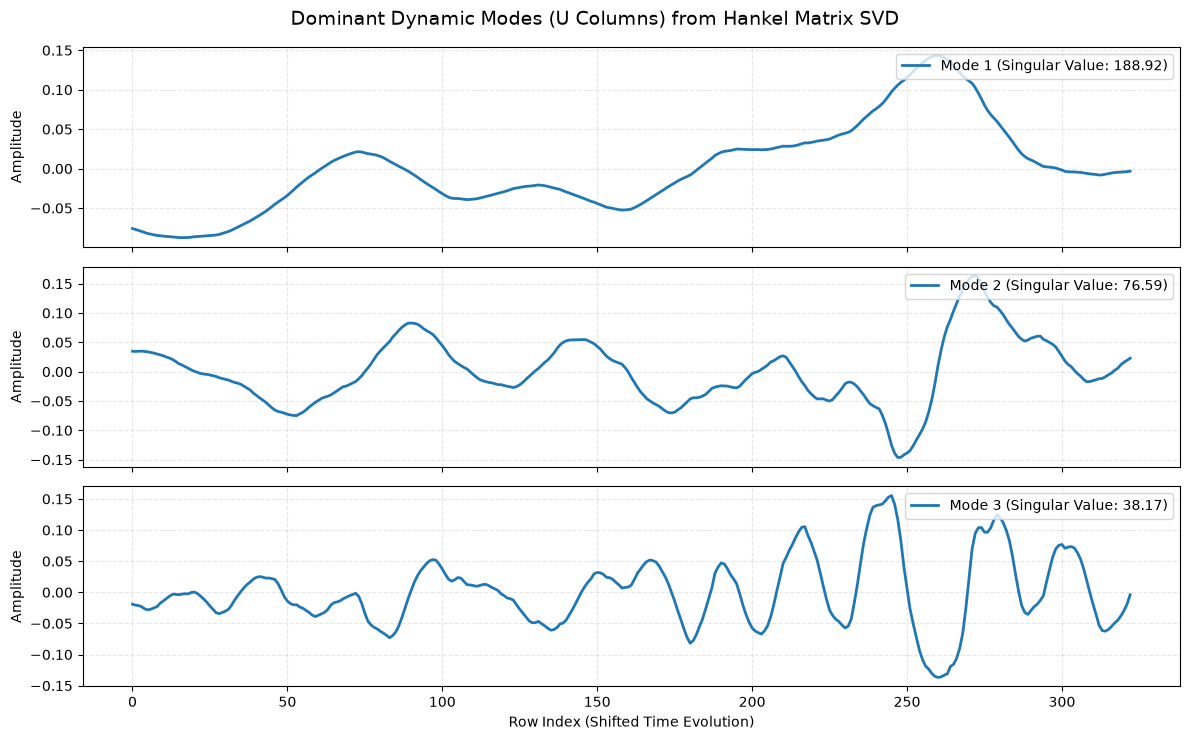

In [215]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define your window length (embedding dimension 'p')
# This is the number of columns in your matrix (the length of each snapshot)
# For example, let's look at a window of 30 tiles. Adjust this based on your dataset size.
p = 30  
x = smoothed_counts.values
N = len(x)
q = N - p + 1  # Number of rows

# 2. Construct the Hankel Matrix H
# Each row is shifted by 1 time step relative to the previous row
H = np.zeros((q, p))
for i in range(q):
    H[i, :] = x[i : i + p]

# 3. Mean-center the matrix column-wise (Standard for physical modes)
H_centered = H - np.mean(H, axis=0)

# 4. Compute SVD
# H_centered = U * S * V.T
# U will have shape (q, p) if full_matrices=False.
U, S, Vt = np.linalg.svd(H_centered, full_matrices=False)

# 5. Plot the first few columns of the U matrix
# These columns represent the temporal evolution of the dominant dynamic modes!
modes_to_plot = 3
fig, axes = plt.subplots(modes_to_plot, 1, figsize=(12, 2.5 * modes_to_plot), sharex=True)

for i in range(modes_to_plot):
    axes[i].plot(U[:, i], label=f'Mode {i+1} (Singular Value: {S[i]:.2f})', linewidth=2)
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].legend(loc='upper right')

axes[-1].set_xlabel('Row Index (Shifted Time Evolution)')
plt.suptitle('Dominant Dynamic Modes (U Columns) from Hankel Matrix SVD', fontsize=14, y=0.98)
plt.tight_layout()
# plt.show()
plt.savefig("./IMG/CratervsLocationModes.png")

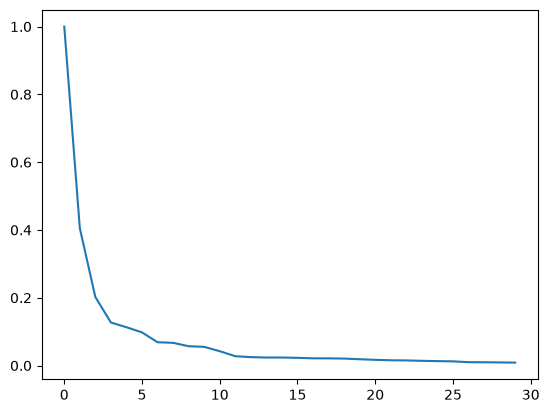

In [219]:
plt.plot(S/np.max(S))
plt.savefig("./IMG/SVD.png")

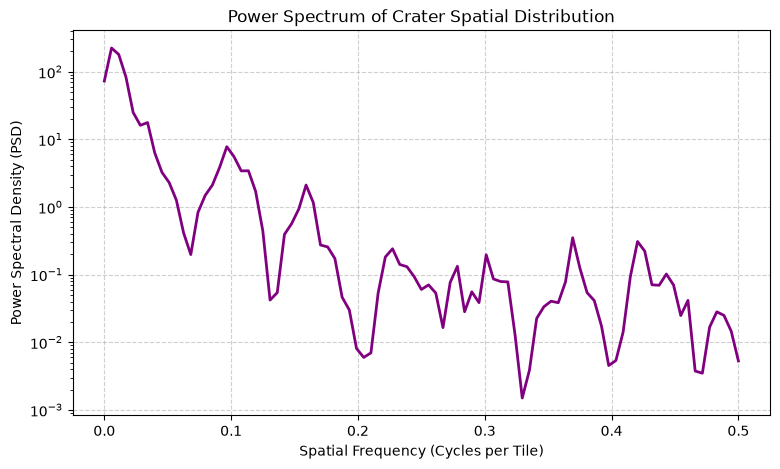

In [197]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Extract the values from your smoothed series
# (Subtracting the mean removes the massive spike at frequency 0)
signal_values = smoothed_counts.values - np.mean(smoothed_counts.values)

# 2. Compute the Power Spectral Density using Welch's method
# fs=1.0 means 1 sample per tile
frequencies, power_spectrum = signal.welch(signal_values, fs=1.0, nperseg=len(signal_values)//2)

# 3. Plot the Power Spectrum
plt.figure(figsize=(9, 5))
plt.plot(frequencies, power_spectrum, color='purple', linewidth=2)

# Styling and Labels
plt.title('Power Spectrum of Crater Spatial Distribution', fontsize=12)
plt.xlabel('Spatial Frequency (Cycles per Tile)', fontsize=10)
plt.ylabel('Power Spectral Density (PSD)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Optional: Add a log scale on the y-axis if the power magnitudes vary wildly
plt.yscale('log')
plt.savefig("./IMG/CratervsLocationPSD.png")
plt.show()

Text(0.5, 0, 'All Tiles (Sorted Chronologically)')

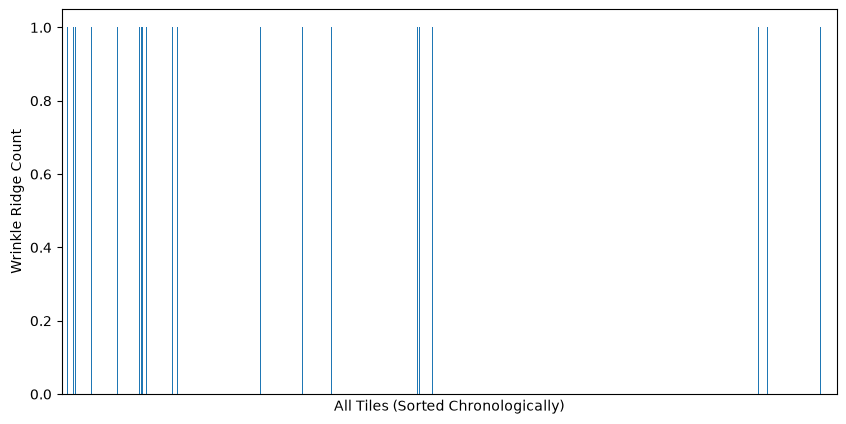

In [111]:
# 1. Get a master list of ALL unique filenames in your dataset
all_filenames = DATA['filename'].unique()

# 2. Filter for Wrinkle ridges and get their counts
wrinkle_counts = DATA[ (DATA['conf'] > 0.4) & (DATA['class_id'] == 'Wrinkle ridge') ]['filename'].value_counts()

# 3. Reindex using ALL filenames, filling missing ones with 0, then sort chronologically
counts_chronological = wrinkle_counts.reindex(all_filenames, fill_value=0).sort_index(ascending=True)

# 4. Plot
ax = counts_chronological.plot(kind='bar', figsize=(10, 5))
ax.get_xaxis().set_ticks([]) # Hide messy labels
ax.set_ylabel('Wrinkle Ridge Count')
ax.set_xlabel('All Tiles (Sorted Chronologically)')

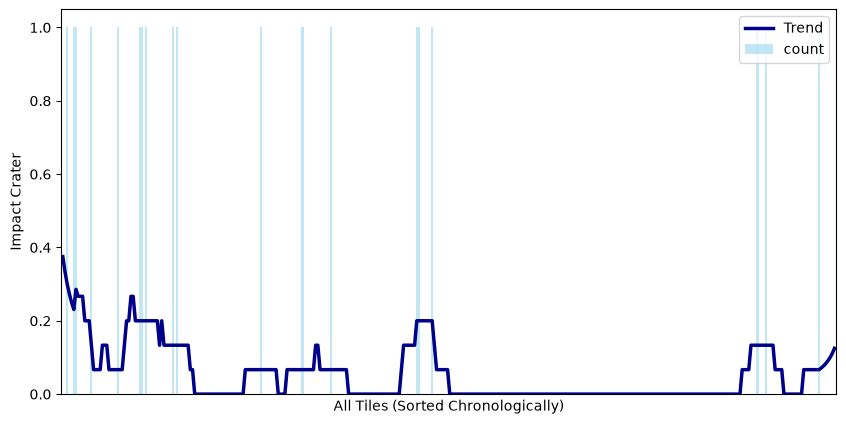

In [112]:
import matplotlib.pyplot as plt

counts_chronological = wrinkle_counts.reindex(all_filenames, fill_value=0).sort_index(ascending=True)
smoothed_counts = counts_chronological.rolling(window=15, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 5))

# Plot raw bars with some transparency (alpha) so they don't overpower the trend
counts_chronological.plot(kind='bar', ax=ax, color='skyblue', alpha=.5, width=1.0)

# Plot the smooth trend line on top
# We use a numeric range for x because bar plots use 0, 1, 2... index positions internally
ax.plot(range(len(smoothed_counts)), smoothed_counts.values, color='darkblue', linewidth=2.5, label='Trend')

ax.get_xaxis().set_ticks([])
ax.set_ylabel('Impact Crater')
ax.set_xlabel('All Tiles (Sorted Chronologically)')
plt.legend()

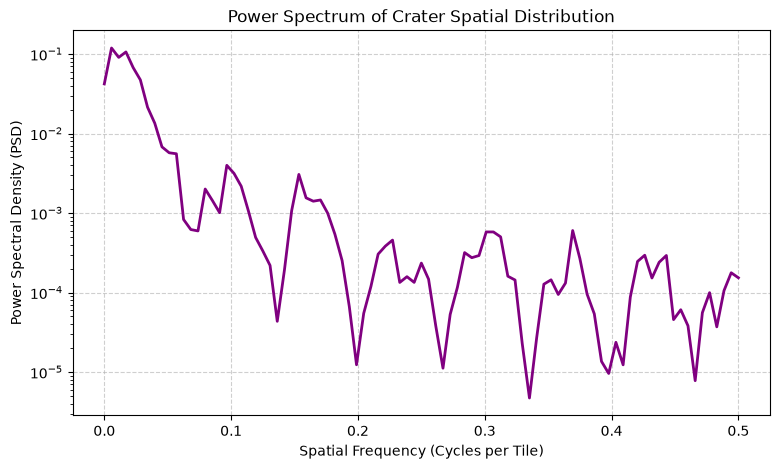

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Extract the values from your smoothed series
# (Subtracting the mean removes the massive spike at frequency 0)
signal_values = smoothed_counts.values - np.mean(smoothed_counts.values)

# 2. Compute the Power Spectral Density using Welch's method
# fs=1.0 means 1 sample per tile
frequencies, power_spectrum = signal.welch(signal_values, fs=1.0, nperseg=len(signal_values)//2)

# 3. Plot the Power Spectrum
plt.figure(figsize=(9, 5))
plt.plot(frequencies, power_spectrum, color='purple', linewidth=2)

# Styling and Labels
plt.title('Power Spectrum of Crater Spatial Distribution', fontsize=12)
plt.xlabel('Spatial Frequency (Cycles per Tile)', fontsize=10)
plt.ylabel('Power Spectral Density (PSD)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Optional: Add a log scale on the y-axis if the power magnitudes vary wildly
plt.yscale('log')

plt.show()

In [128]:
DATA[(DATA['w']>0.001) & DATA['conf'] > 0.4]

,filename,class_id,x,y,w,h,type,conf
37,tile_001007.txt,Impact Crater,0.909907,0.118910,0.018974,0.020071,f1,0.5
54,tile_002045.txt,Impact Crater,0.622925,0.801689,0.022760,0.030564,f1,0.5
57,tile_002140.txt,Impact Crater,0.914711,0.842793,0.018444,0.019851,f1,0.5
59,tile_002235.txt,Impact Crater,0.914645,0.092888,0.018305,0.019430,f1,0.5
62,tile_002412.txt,Impact Crater,0.432881,0.440817,0.022304,0.026382,f1,0.5
...,...,...,...,...,...,...,...,...
1711,tile_001395.txt,lobate_scarp,0.866528,0.781358,0.266943,0.043564,f2,0.5
1712,tile_001420.txt,lobate_scarp,0.638314,0.828764,0.021725,0.026947,f2,0.5
1713,tile_001733.txt,lobate_scarp,0.989638,0.358885,0.017657,0.023972,f2,0.5
1714,tile_002606.txt,lobate_scarp,0.011680,0.434398,0.022852,0.035852,f2,0.5


In [135]:
DATA['area'] = DATA['w']*DATA['h']

In [136]:
DATA

,filename,class_id,x,y,w,h,type,conf,area
0,tile_000075.txt,Impact Crater,0.781250,0.406250,0.000000,0.000000,f1,0.5,0.000000
1,tile_000075.txt,Impact Crater,0.781250,0.343750,0.000000,0.000000,f1,0.5,0.000000
2,tile_000075.txt,Impact Crater,0.718750,0.718750,0.000000,0.000000,f1,0.5,0.000000
3,tile_000075.txt,Impact Crater,0.718750,0.406250,0.000000,0.000000,f1,0.5,0.000000
4,tile_000075.txt,Impact Crater,0.718750,0.781250,0.000000,0.000000,f1,0.5,0.000000
...,...,...,...,...,...,...,...,...,...
1711,tile_001395.txt,lobate_scarp,0.866528,0.781358,0.266943,0.043564,f2,0.5,0.011629
1712,tile_001420.txt,lobate_scarp,0.638314,0.828764,0.021725,0.026947,f2,0.5,0.000585
1713,tile_001733.txt,lobate_scarp,0.989638,0.358885,0.017657,0.023972,f2,0.5,0.000423
1714,tile_002606.txt,lobate_scarp,0.011680,0.434398,0.022852,0.035852,f2,0.5,0.000819


<Axes: >

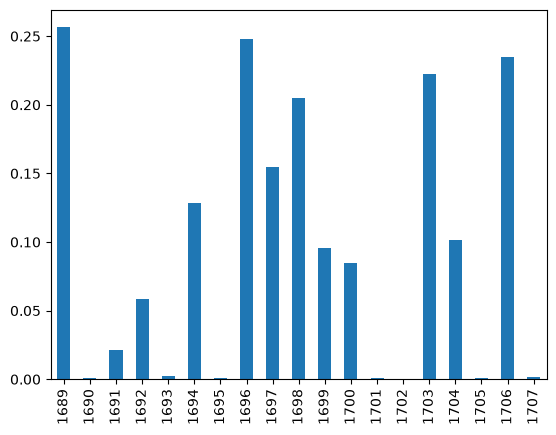

In [142]:
DATA[DATA['class_id'] == 'Wrinkle ridge']['area'].plot(kind='bar')

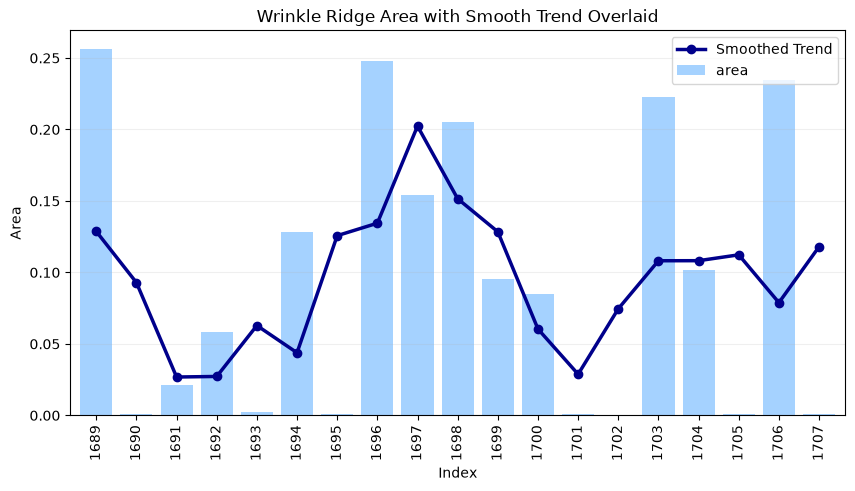

In [143]:
import matplotlib.pyplot as plt

# 1. Extract raw series and compute rolling mean
wrinkle_area = DATA[DATA['class_id'] == 'Wrinkle ridge']['area']
smoothed_area = wrinkle_area.rolling(window=3, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 5))

# 2. Plot original raw data bars with a light transparency
wrinkle_area.plot(kind='bar', ax=ax, color='dodgerblue', alpha=0.4, width=0.8)

# 3. Plot the trend line on top
# Because pandas bar charts use categorical integer mapping (0, 1, 2...) for the x-axis alignment, 
# we map the line coordinates to match the bar center index alignment.
ax.plot(range(len(smoothed_area)), smoothed_area.values, color='darkblue', linewidth=2.5, marker='o', label='Smoothed Trend')

# Styling
ax.set_ylabel('Area')
ax.set_xlabel('Index')
ax.set_title('Wrinkle Ridge Area with Smooth Trend Overlaid')
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()

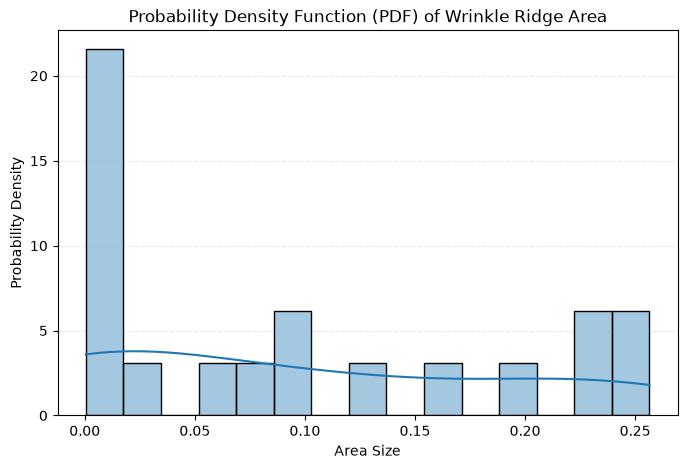

In [144]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract the area values
wrinkle_area = DATA[DATA['class_id'] == 'Wrinkle ridge']['area']

# 2. Plot the Histogram + PDF Curve
plt.figure(figsize=(8, 5))
sns.histplot(wrinkle_area, kde=True, stat="density", color="tab:blue", bins=15, alpha=0.4)

# Styling
plt.title('Probability Density Function (PDF) of Wrinkle Ridge Area', fontsize=12)
plt.xlabel('Area Size', fontsize=10)
plt.ylabel('Probability Density', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.show()

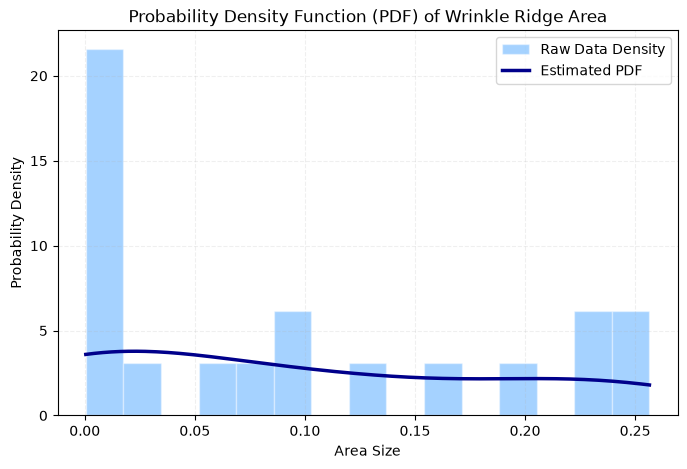

In [198]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. Extract area data
wrinkle_area = DATA[DATA['class_id'] == 'Wrinkle ridge']['area'].dropna().values

# 2. Calculate the mathematical PDF curve
pdf_estimator = gaussian_kde(wrinkle_area)
x_evaluation = np.linspace(wrinkle_area.min(), wrinkle_area.max(), 200)
pdf_values = pdf_estimator(x_evaluation)

# 3. Plot
plt.figure(figsize=(8, 5))

# Plot the density normalized histogram
plt.hist(wrinkle_area, bins=15, density=True, alpha=0.4, color='dodgerblue', edgecolor='white', label='Raw Data Density')

# Plot the smooth PDF line
plt.plot(x_evaluation, pdf_values, color='darkblue', linewidth=2.5, label='Estimated PDF')

# Styling
plt.title('Probability Density Function (PDF) of Wrinkle Ridge Area', fontsize=12)
plt.xlabel('Area Size', fontsize=10)
plt.ylabel('Probability Density', fontsize=10)
plt.legend()
plt.grid(True, alpha=0.2, linestyle='--')

plt.show()

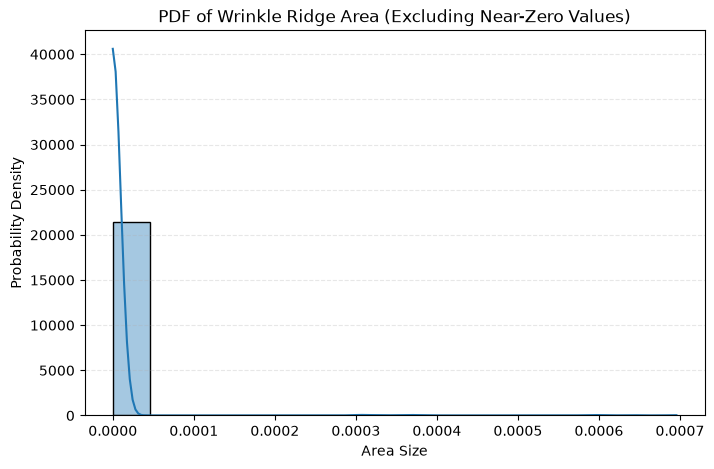

In [225]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract and filter: keep only rows where class is 'Wrinkle ridge' AND area > 0.01
filtered_area = DATA[
    (DATA['class_id'] == 'Impact Crater') 
]['area']

# 2. Plot the Histogram + PDF Curve
plt.figure(figsize=(8, 5))
sns.histplot(filtered_area, kde=True, stat="density", color="tab:blue", bins=15, alpha=0.4)

# Styling
plt.title('PDF of Wrinkle Ridge Area (Excluding Near-Zero Values)', fontsize=12)
plt.xlabel('Area Size', fontsize=10)
plt.ylabel('Probability Density', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.savefig("./IMG/PDFCraterArea.png")

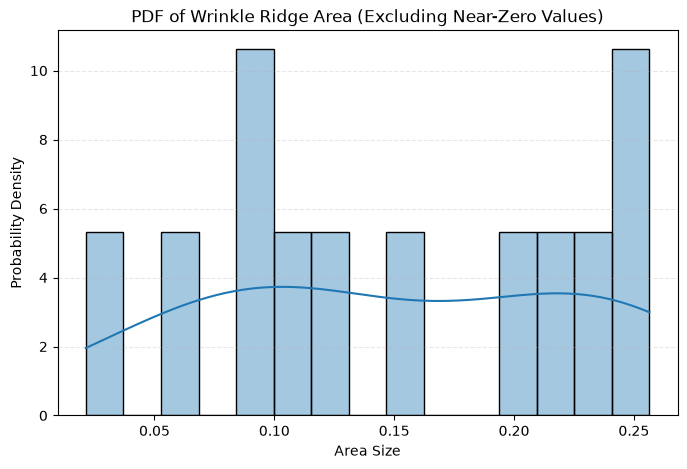

In [201]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract and filter: keep only rows where class is 'Wrinkle ridge' AND area > 0.01
filtered_area = DATA[
    (DATA['class_id'] == 'Wrinkle ridge') & 
    (DATA['area'] > 0.01)
]['area']

# 2. Plot the Histogram + PDF Curve
plt.figure(figsize=(8, 5))
sns.histplot(filtered_area, kde=True, stat="density", color="tab:blue", bins=15, alpha=0.4)

# Styling
plt.title('PDF of Wrinkle Ridge Area (Excluding Near-Zero Values)', fontsize=12)
plt.xlabel('Area Size', fontsize=10)
plt.ylabel('Probability Density', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.savefig("./IMG/PDFWrinkleRidgeArea.png")

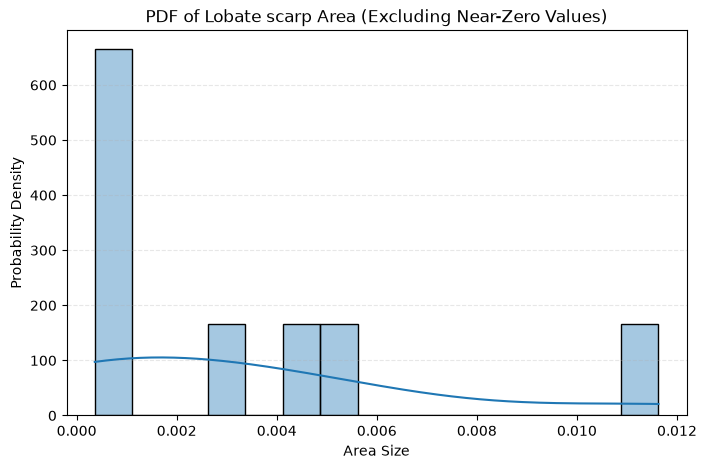

In [205]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract and filter: keep only rows where class is 'Wrinkle ridge' AND area > 0.01
filtered_area = DATA[
    (DATA['class_id'] == 'lobate_scarp') & 
    (DATA['area'] > 0.00001)
]['area']

# 2. Plot the Histogram + PDF Curve
plt.figure(figsize=(8, 5))
sns.histplot(filtered_area, kde=True, stat="density", color="tab:blue", bins=15, alpha=0.4)

# Styling
plt.title('PDF of Lobate scarp Area (Excluding Near-Zero Values)', fontsize=12)
plt.xlabel('Area Size', fontsize=10)
plt.ylabel('Probability Density', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.savefig("./IMG/PDFlobate_scarpArea.png")
plt.show()

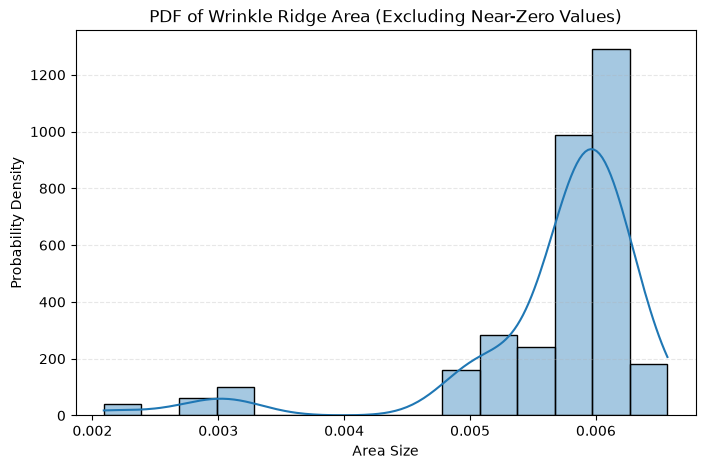

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract and filter: keep only rows where class is 'Wrinkle ridge' AND area > 0.01
filtered_area = DATA[
    (DATA['class_id'] == 'irregular_mare_patch') & 
    (DATA['area'] > 0.00001)
]['area']

# 2. Plot the Histogram + PDF Curve
plt.figure(figsize=(8, 5))
sns.histplot(filtered_area, kde=True, stat="density", color="tab:blue", bins=15, alpha=0.4)

# Styling
plt.title('PDF of Wrinkle Ridge Area (Excluding Near-Zero Values)', fontsize=12)
plt.xlabel('Area Size', fontsize=10)
plt.ylabel('Probability Density', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.show()

In [153]:
DATA['class_id'].unique()

array(['Impact Crater', 'apollo_site', 'pit_skylight',
       'irregular_mare_patch', 'Wrinkle ridge', 'lobate_scarp'],
      dtype=object)

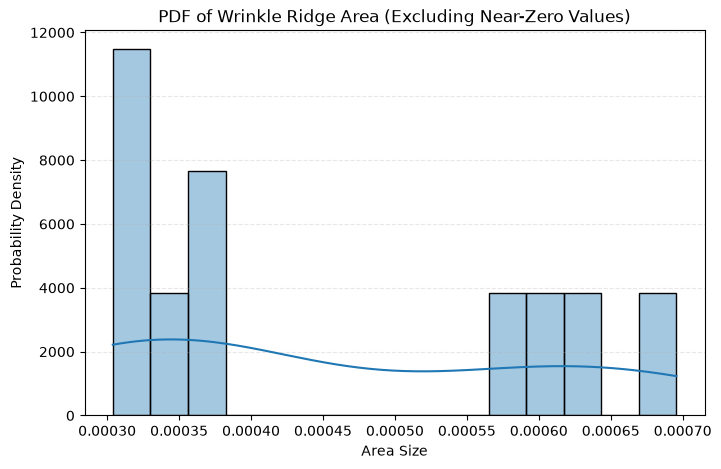

In [158]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract and filter: keep only rows where class is 'Wrinkle ridge' AND area > 0.01
filtered_area = DATA[
    (DATA['class_id'] == 'Impact Crater') & 
    (DATA['area'] > 0.00001)
]['area']

# 2. Plot the Histogram + PDF Curve
plt.figure(figsize=(8, 5))
sns.histplot(filtered_area, kde=True, stat="density", color="tab:blue", bins=15, alpha=0.4)

# Styling
plt.title('PDF of Wrinkle Ridge Area (Excluding Near-Zero Values)', fontsize=12)
plt.xlabel('Area Size', fontsize=10)
plt.ylabel('Probability Density', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.show()

In [157]:
DATA

,filename,class_id,x,y,w,h,type,conf,area
0,tile_000075.txt,Impact Crater,0.781250,0.406250,0.000000,0.000000,f1,0.5,0.000000
1,tile_000075.txt,Impact Crater,0.781250,0.343750,0.000000,0.000000,f1,0.5,0.000000
2,tile_000075.txt,Impact Crater,0.718750,0.718750,0.000000,0.000000,f1,0.5,0.000000
3,tile_000075.txt,Impact Crater,0.718750,0.406250,0.000000,0.000000,f1,0.5,0.000000
4,tile_000075.txt,Impact Crater,0.718750,0.781250,0.000000,0.000000,f1,0.5,0.000000
...,...,...,...,...,...,...,...,...,...
1711,tile_001395.txt,lobate_scarp,0.866528,0.781358,0.266943,0.043564,f2,0.5,0.011629
1712,tile_001420.txt,lobate_scarp,0.638314,0.828764,0.021725,0.026947,f2,0.5,0.000585
1713,tile_001733.txt,lobate_scarp,0.989638,0.358885,0.017657,0.023972,f2,0.5,0.000423
1714,tile_002606.txt,lobate_scarp,0.011680,0.434398,0.022852,0.035852,f2,0.5,0.000819


In [223]:
DATA[ DATA['class_id'] == 'Impact Crater']

,filename,class_id,x,y,w,h,type,conf,area
0,tile_000075.txt,Impact Crater,0.78125,0.40625,0.0,0.0,f1,0.5,0.0
1,tile_000075.txt,Impact Crater,0.78125,0.34375,0.0,0.0,f1,0.5,0.0
2,tile_000075.txt,Impact Crater,0.71875,0.71875,0.0,0.0,f1,0.5,0.0
3,tile_000075.txt,Impact Crater,0.71875,0.40625,0.0,0.0,f1,0.5,0.0
4,tile_000075.txt,Impact Crater,0.71875,0.78125,0.0,0.0,f1,0.5,0.0
...,...,...,...,...,...,...,...,...,...
1340,tile_009005.txt,Impact Crater,0.65625,0.53125,0.0,0.0,f1,0.5,0.0
1341,tile_009006.txt,Impact Crater,0.53125,0.21875,0.0,0.0,f1,0.5,0.0
1342,tile_009006.txt,Impact Crater,0.46875,0.28125,0.0,0.0,f1,0.5,0.0
1343,tile_009008.txt,Impact Crater,0.59375,0.78125,0.0,0.0,f1,0.5,0.0


In [227]:
DATA['class_id'].unique()

array(['Impact Crater', 'apollo_site', 'pit_skylight',
       'irregular_mare_patch', 'Wrinkle ridge', 'lobate_scarp'],
      dtype=object)